In [1]:
print(2^2)

0


In [7]:
arr = [3090.8,2831.5,2585.6,2324.8,2074.5,1831.1,1593.4]
result = [0,0,0,0,0,0,0]
i = 0 

for i in range(6):
    result[i] = (1 / arr[i]) * (1 / arr[i+1]) / (2 * 2.67 * ((1 / arr[i+1]) - (1 / arr[i])) * 0.99788)

result

[0.0007237322205335094,
 0.0007631710645967424,
 0.0007195696502466998,
 0.0007497553527140984,
 0.0007710097156299874,
 0.000789498379404036,
 0]

In [5]:
votes = ["李华","李华","王恒","黄晨","赵元","赵元","王恒","秦月","秦月","李华","李华","赵元","黄晨","王恒","秦月","李华","黄晨","王恒","赵元","赵元","李华"]
tickets = {}
names = set(votes)
for name in names:
    tickets[name] = votes.count(name)
tickets

{'李华': 6, '王恒': 4, '黄晨': 3, '赵元': 5, '秦月': 3}

<Axes: xlabel='Month'>

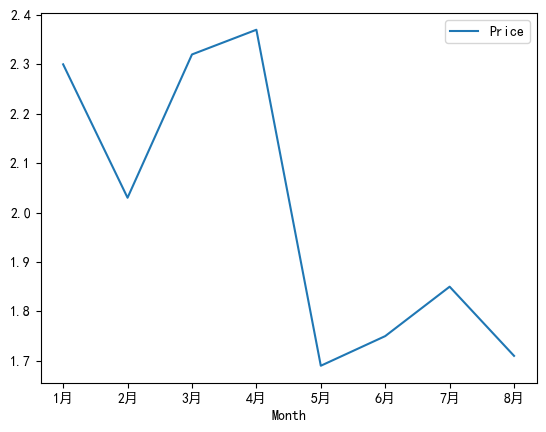

In [2]:
import pandas

# 读取数据，指定日期为索引列
data = pandas.read_csv(
    'E:\\Documents\\data.csv',
    index_col='Month',encoding='GB2312'
)
# 绘图过程中
import matplotlib.pyplot as plt
# 用来正常显示中文标签
plt.rcParams['font.sans-serif'] = ['SimHei']
# 用来正常显示负号
plt.rcParams['axes.unicode_minus'] = False
# 查看趋势图
data.plot()  # 有增长趋势，不平稳

原始序列的ADF检验结果为:                                 Price
Test Statistic Value         -1.49025
p-value                      0.538329
Lags Used                           0
Number of Observations Used         7
Critical Value(1%)           -4.93869
Critical Value(5%)          -3.477583
Critical Value(10%)         -2.843868


C:\Users\贺正泽\AppData\Local\Temp\ipykernel_4192\1941212836.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_acf(data).show()
C:\Users\贺正泽\AppData\Local\Temp\ipykernel_4192\1941212836.py:31: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#r

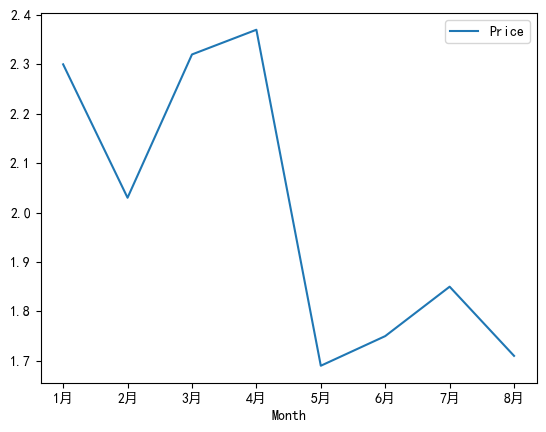

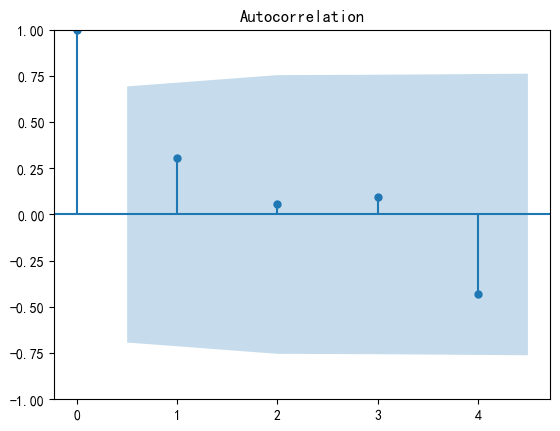

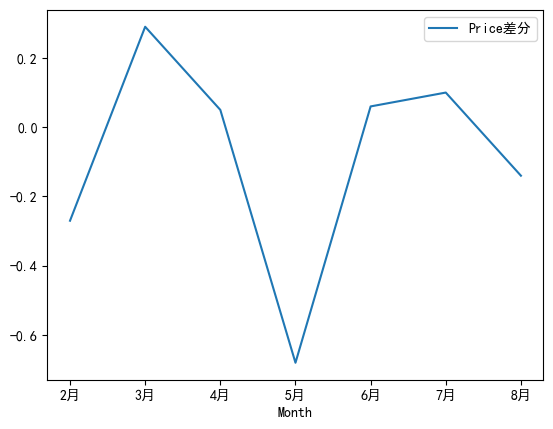

C:\Users\贺正泽\AppData\Local\Temp\ipykernel_4192\1941212836.py:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_acf(D_data).show()


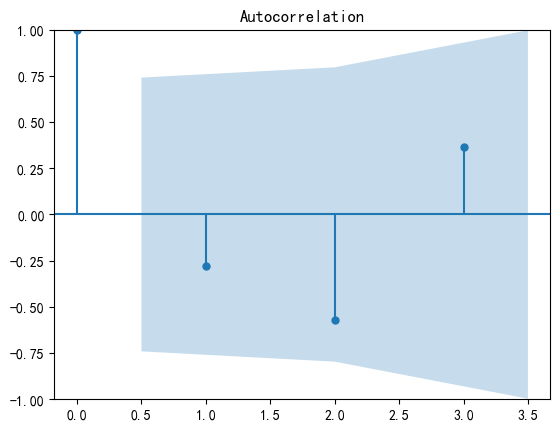

C:\Users\贺正泽\AppData\Local\Temp\ipykernel_4192\1941212836.py:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_pacf(D_data).show()


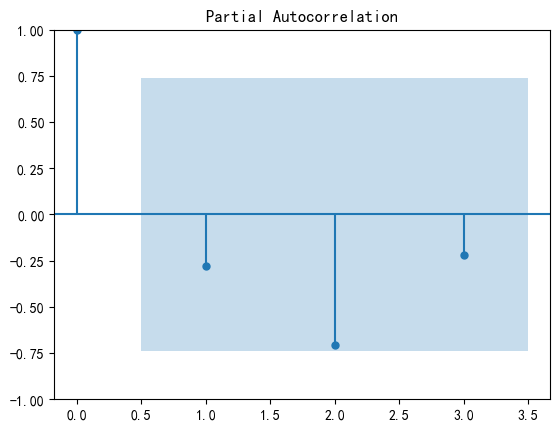

In [12]:
import pandas

# 读取数据，指定日期为索引列
data = pandas.read_csv(
    'E:\\Documents\\data.csv',
    index_col='Month',encoding='GB2312'
)
# 绘图过程中
import matplotlib.pyplot as plt
# 用来正常显示中文标签
plt.rcParams['font.sans-serif'] = ['SimHei']
# 用来正常显示负号
plt.rcParams['axes.unicode_minus'] = False
# 查看趋势图
data.plot()

# 自相关图（）

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(data).show() 

# 1 平稳性检测
from statsmodels.tsa.stattools import adfuller as ADF
def tagADF(t):
    result = pandas.DataFrame(index=[
        "Test Statistic Value", "p-value", "Lags Used",
        "Number of Observations Used",
        "Critical Value(1%)", "Critical Value(5%)", "Critical Value(10%)"
    ], columns=['Price']
    );
    result['Price']['Test Statistic Value'] = t[0]
    result['Price']['p-value'] = t[1]
    result['Price']['Lags Used'] = t[2]
    result['Price']['Number of Observations Used'] = t[3]
    result['Price']['Critical Value(1%)'] = t[4]['1%']
    result['Price']['Critical Value(5%)'] = t[4]['5%']
    result['Price']['Critical Value(10%)'] = t[4]['10%']
    return result;

print('原始序列的ADF检验结果为:', tagADF(ADF(data[u'Price'])))  # 添加标签后展现

# 2 进行数据差分，一般一阶差分就可以
D_data = data.diff(1).dropna()
D_data.columns = [u'Price差分']
# 差分图趋势查看
D_data.plot()
plt.show()
# 附加：查看自相关系数合片自相关系数（查分之后），可以用于平稳性的检测，也可用于定阶系数预估
# 自相关图
plot_acf(D_data).show()
plt.show()
# 偏自相关图
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(D_data).show()